# Problem set 2: Optimization and Root Finding

We will take a look at solving the canonical utility maximization problem for the consumer.  

**Table of contents**<a id='toc0_'></a>    
- 1. [CES function](#toc1_)    
- 2. [Value-of-choice](#toc2_)    
- 3. [Brute-force grid search](#toc3_)    
- 4. [Bisection](#toc4_)    
- 5. [Newton's Method](#toc5_)    
- 6. [scipy.optimize](#toc6_)    
- 7. [More scipy optimizers](#toc7_)    
- 8. [Sensitivity: Price Shock](#toc8_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import numpy as np

## 1. <a id='toc1_'></a>[CES function](#toc0_)

Implement a Python version of this function:

$$ 
u(x_1,x_2) = (\alpha x_1^{-\beta} + (1-\alpha) x_2^{-\beta})^{-1/\beta} 
$$

In [2]:
# write your own code here

In [3]:
import A1

## 2. <a id='toc2_'></a>[Value-of-choice](#toc0_)

The consumer faces the following budget constraint:

$$ p_1 x_1 + p_2 x_2 \le I, \quad x_1 \ge 0,\; x_2 \ge 0. $$

**Tasks:** Use your function from above that contains the CES utility function and embed it into another function *value_of_choice_ces* that returns the value of utility *u*. Use only $x_1$ as input into the function and compute $x_2$ within the function,

$$x_2 = (I - p_1x_1)/p_2.$$

Evaluate for some $x_1$ values.

In [4]:
# use these baseline parameters
alpha = 0.5
beta = 0.5
I = 10
p1 = 1
p2 = 2
x1_vec = [0.5,1.0,1.5]

In [5]:
# write your own code here

In [6]:
import A2

Next, we will compare different methods to solve the consumer problem.

## 3. <a id='toc3_'></a>[Brute-force grid search](#toc0_)

Set up a grid of the budget set and solve the consumer problem on the grid.

**Idea:** Search over a grid for  $x_1 \in [0, I/p_1]$, and  $x_2 \in [0, I/p_2]$ to find the values of $x_1$ and $x_2$ that maximize utility.


**Task A**: Modify the grid search function below to add the additional parameter for the CES utility function $\beta$ and print the results.

In [7]:
from types import SimpleNamespace
from grid_solve import print_solution

def find_best_choice(u_func,alpha,I,p1,p2,N1,N2,do_print=True):
    
    # a. allocate numpy arrays
    shape_tuple = (N1,N2)
    x1_values = np.empty(shape_tuple)
    x2_values = np.empty(shape_tuple)
    u_values = np.empty(shape_tuple)
    
    # b. start from guess of x1=x2=0
    x1_best = 0
    x2_best = 0
    u_best = u_func(0,0,alpha=alpha)
    
    # c. loop through all possibilities
    for i in range(N1):
        for j in range(N2):
            
            # i. x1 and x2 (chained assignment)
            x1_values[i,j] = x1 = (i/(N1-1))*I/p1
            x2_values[i,j] = x2 = (j/(N2-1))*I/p2
            
            # ii. utility
            if p1*x1 + p2*x2 <= I: # u(x1,x2) if expenditures <= income 
                u_values[i,j] = u_func(x1,x2,alpha=alpha)
            else: # u(0,0) if expenditures > income, not allowed
                u_values[i,j] = u_func(0,0,alpha=alpha)
            
            # iii. check if best sofar
            if u_values[i,j] > u_best:
                x1_best = x1_values[i,j]
                x2_best = x2_values[i,j] 
                u_best = u_values[i,j]
    
    # d. print
    if do_print:
        print_solution(x1_best,x2_best,u_best,I,p1,p2)

    return SimpleNamespace(x1_best=x1_best,
                           x2_best=x2_best,
                           u_best=u_best,
                           x1_values=x1_values,
                           x2_values=x2_values,
                           u_values=u_values)

# sol = find_best_choice(u_func,alpha,I,p1,p2,N1,N2,do_print=True)

In [8]:
import A3_A
N1 = 100
N2 = 100
A3_A.find_best_choice(A1.utility_ces, alpha, beta, I, p1, p2, N1, N2)

x1 = 4.44444
x2 = 2.77778
u  = 3.46557
I-p1*x1-p2*x2 = 0.00000000
x1*p1/I = 0.44444


**Smarter grid search (monotonicity).** Because CES utility is strictly increasing in both goods, the optimum must lie *on* the budget line. This lets you turn the 2D search into a **1D search**: choose a grid for $x_1 \in [0, I/p_1]$, set $x_2 = (I-p_1 x_1)/p_2$, and keep the best.

**Task B:** Adapt `find_best_choice_monotone` from lecture 5 to the CES utility (add the `beta` argument). Run it with `N=10000` points on the budget line and compare with the 2D grid above, which used the same number of evaluations ($100\times100$). Which is more accurate?

In [9]:
# write your own code here

In [10]:
import A3_B
A3_B.find_best_choice_monotone(A1.utility_ces, alpha, beta, I, p1, p2, N=10000)

x1 = 4.42444
x2 = 2.78778
u  = 3.46561
I-p1*x1-p2*x2 = 0.00000000
x1*p1/I = 0.44244


## 4. <a id='toc4_'></a>[Bisection](#toc0_)

Use the bisection function from the lecture. Make sure you understand what it does first. 

Then, define the first‑order condition of the consumer problem with the modified utility function, which we can enforce by a **single equation in $ x_1 $**:  


_Note: You are not required to derive the FOC yourself, take the solution as given and implement it_ 

FOC (interior):
$$\frac{\partial u/\partial x_1}{\partial u/\partial x_2}
=\frac{\alpha\,x_1^{-(\beta+1)}}{(1-\alpha)\,x_2^{-(\beta+1)}}
=\frac{\alpha}{1-\alpha}\left(\frac{x_2}{x_1}\right)^{\beta+1}
=\frac{p_1}{p_2}.$$

Single equation in $x_1$ (with $x_2(x_1)=\tfrac{I-p_1x_1}{p_2}$):
$$f(x_1)\equiv \frac{\alpha}{1-\alpha}\left(\frac{I-p_1x_1}{p_2x_1}\right)^{\beta+1}-\frac{p_1}{p_2}=0.$$

We solve $ f(x_1) = 0 $ on $[0, I/p_1]$ using **bisection**.


**Algorithm:** `bisection()`

1. Set $a_0 = a$ and $b_0 = b$ where $f(a)$ and $f(b)$ have opposite sign, $f(a_0)f(b_0)<0$.
2. Compute $f(m_0)$ where $m_0 = (a_0 + b_0)/2$ is the midpoint.
3. Determine the next sub-interval $[a_1,b_1]$:
  * If $f(a_0)f(m_0) < 0$ (different signs) then $a_1 = a_0$ and $b_1 = m_0$ (i.e. focus on the range $[a_0,m_0]$).
  * If $f(m_0)f(b_0) < 0$ (different signs) then $a_1 = m_0$ and $b_1 = b_0$ (i.e. focus on the range $[m_0,b_0]$).
4. Repeat step 2 and step 3 until $|f(m_k)| < \epsilon$.

In [11]:
def bisection(f, a, b, tol=1e-10, max_iter=500):
    
    fa, fb = f(a), f(b)

    if np.isnan(fa) or np.isnan(fb):
        raise ValueError('f(a) or f(b) is NaN.')
    
    if fa == 0.0: return a, 0
    if fb == 0.0:  return b, 0
    
    if fa*fb > 0:
        raise ValueError('Bisection: root not bracketed. Choose a,b with opposite signs.')
    
    it = 0
    while (b - a) > tol and it < max_iter:
        
        m  = 0.5*(a + b)
        fm = f(m)
        
        if fm == 0.0:
            a = b = m
            break
        
        if fa*fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
            
        it += 1

    return 0.5*(a + b), it

In [12]:
# a. set up the function f(x1) = 0 to solve for x1*
## write your functions here

# b. choose a bracket around the known solution
# a_bis, b_bis
# set the tolerance and the maximum number of iterations

# c. run the bisection method, compute x2 and print the solution
# x1_bis, it_bis = bisection(F, a_bis, b_bis, tol=1e-15, max_iter=500)
# print(f'Bisection: x1*={x1_bis:.10f}, x2*={x2_bis:.10f}, iterations={it_bis}')

In [13]:
import A4
A4.solve_with_bisection(alpha,beta,I,p1,p2)

x1 = 4.42493
x2 = 2.78753
u  = 3.46561
I-p1*x1-p2*x2 = 0.00000000
x1*p1/I = 0.44249
iterations = 44


## 5. <a id='toc5_'></a>[Newton's Method](#toc0_)


Apply Newton on $ f(x_1)=0 $ where $f$ is defined above.  
We compute $ f'(x_1)$ analytically for the CES consumer problem:

**Fully expanded form**
$
f'(x_1)\;=\;-\;\frac{\alpha}{1-\alpha}\,(\beta+1)\,\frac{I}{p_2\,x_1^{2}}
\left(\frac{I-p_1 x_1}{p_2\,x_1}\right)^{\beta}.
$

In [14]:
## write your code here

## Hint: use f from the exercise above, define fprime (the expanded form from above) as a function,
# and use the Newton function from the lecture.

In [15]:
import A5
A5.solve_with_newton(alpha,beta,I,p1,p2)

x1 = 4.42493
x2 = 2.78753
u  = 3.46561
I-p1*x1-p2*x2 = 0.00000000
x1*p1/I = 0.44249
iterations = 5


**Newton without the analytic derivative.** Deriving $f'(x_1)$ by hand is error-prone. Instead approximate it with a forward difference (see lecture 5):
$$f'(x_1) \approx \frac{f(x_1+\Delta)-f(x_1)}{\Delta}, \qquad \Delta \text{ small}.$$

**Task:** Re-solve $f(x_1)=0$ with Newton using a *numerical* derivative and compare the number of iterations and the accuracy with the analytic version above.

In [16]:
# write your own code here

In [17]:
import A5
A5.solve_with_newton_numderiv(alpha,beta,I,p1,p2)

x1 = 4.42493
x2 = 2.78753
u  = 3.46561
I-p1*x1-p2*x2 = 0.00000000
x1*p1/I = 0.44249
iterations = 5


## 6. <a id='toc6_'></a>[scipy.optimize](#toc0_)

**Task A:** Solve the consumer problem now using the `scipy.optimize.minimize_scalar` function. Define adequate bounds.

In [18]:
### write your code here ###

In [19]:
import A6
A6.solve_with_scipy_minimize(A1.utility_ces, alpha, beta, I, p1, p2)

x1 = 4.42493
x2 = 2.78753
u  = 3.46561
I-p1*x1-p2*x2 = 0.00000000
x1*p1/I = 0.44249
iterations = 10
function_calls = 10


**Use `scipy.optimize.root_scalar`.** scipy has robust root finders. The recommended one is **`brentq`**, which combines the safety of bisection with faster interpolation (lecture 5, root finding §5).

**Task B:** Solve the FOC `f(x1)=0` with `optimize.root_scalar(f, bracket=[a,b], method='brentq')`. Print the root and compare `iterations`/`function_calls` with your hand-coded bisection and Newton.

In [20]:
# write your own code here

In [21]:
import A6
A6.solve_with_scipy_root_scalar(A1.utility_ces, alpha, beta, I, p1, p2)

x1 = 4.42493
x2 = 2.78753
u  = 3.46561
I-p1*x1-p2*x2 = 0.00000000
x1*p1/I = 0.44249
iterations = 11
function_calls = 12


## 7. <a id='toc7_'></a>[More scipy optimizers](#toc0_)

Solve the problem now with *SLSQP* and *Nelder-Mead* in `scipy.optimize.minimize`.

Compare the number of iterations, function evaluations, speed, and precision.


In [22]:
### write your code here ###

In [23]:
import A7
A7.compare_optimizers(A1.utility_ces,alpha,beta,I,p1,p2)


SLSQP (bounded)
x1 = 4.42521
x2 = 2.78739
u  = 3.46561
I-p1*x1-p2*x2 = 0.00000000
x1*p1/I = 0.44252
iterations = 4  function_calls = 8
time = 8.9 ms

Nelder-Mead (unconstrained)
x1 = 4.42493
x2 = 2.78754
u  = 3.46561
I-p1*x1-p2*x2 = 0.00000000
x1*p1/I = 0.44249
iterations = 15  function_calls = 30
time = 4.1 ms


## 8. <a id='toc8_'></a>[Sensitivity: Price Shock](#toc0_)

**Goal.** See how the optimal bundle and the consumer's welfare react when the price of good 1 **doubles** ($p_1 \rightarrow 2p_1$), and how that reaction depends on the **curvature** of the CES utility, controlled by $\beta$.

The parameter $\beta$ sets how *curved* the indifference curves are:
- a **small** $\beta$ gives nearly straight indifference curves: the two goods are close substitutes and the consumer rebalances easily;
- a **large** $\beta$ gives sharply curved (more L-shaped) indifference curves: the goods behave more like complements and the consumer is reluctant to rebalance.

See **Problem Set 1** for an illustration of this.

**Task A:**
- For each $\beta \in \{0.1, 0.3, 0.5, 0.7, 0.9\}$, compute the optimum $(x_1^\star, x_2^\star, u^\star)$ at the baseline prices and after $p_1$ doubles.
- For each $\beta$, report the **percentage change** of each relative to its baseline.
- Plot two panels: **Panel A** the quantity responses ($x_1^\star$ and $x_2^\star$), **Panel B** the welfare response ($u^\star$).

In [24]:
## write your code

  beta      %dx1      %dx2       %du
------------------------------------
  0.10    -48.37     -3.05    -28.90
  0.30    -45.66     -7.39    -28.30
  0.50    -43.50    -10.31    -27.86
  0.70    -41.74    -12.41    -27.52
  0.90    -40.28    -13.99    -27.26


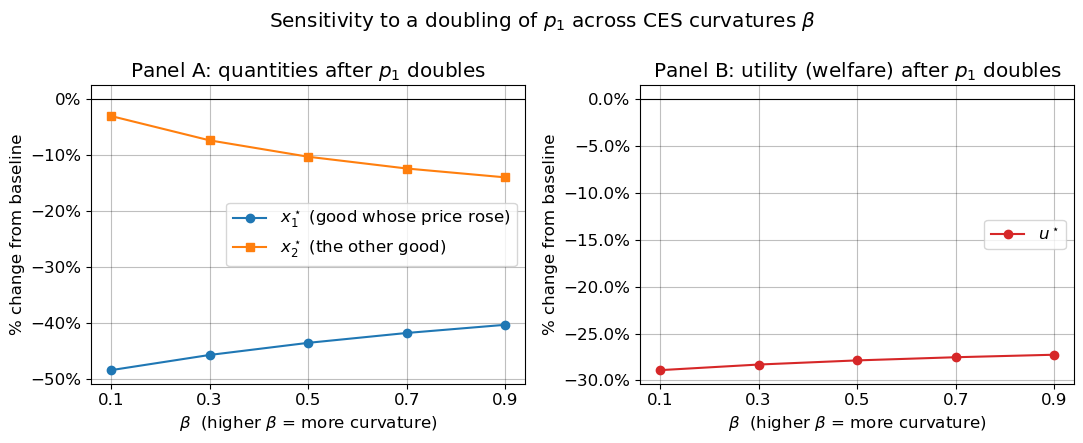

In [25]:
import A8
A8.price_shock_sensitivity(A1.utility_ces, alpha, I, p1, p2)

**Interpretation:**

- **Good 1 (its price rose).** $x_1^\star$ *always* falls, and it falls *more* the **lower** the curvature (small $\beta$): with nearly straight indifference curves the consumer easily flees the now-expensive good. With high curvature (large $\beta$) demand is rigid and $x_1^\star$ moves less.

- **Good 2 (price unchanged).** Here $x_2^\star$ also falls for every $\beta$, but *how much* depends on the curvature:
  - with **low** curvature the consumer reallocates *out of good 1 and protects good 2*, so $x_2^\star$ barely moves;
  - with **high** curvature the goods must be consumed in nearly fixed proportions, so the forced cut in $x_1$ drags $x_2$ down with it.

  Behind this lies a tug-of-war: a *substitution effect* pushes **toward** the now-relatively-cheaper good 2, while an *income effect* (lower real income) pushes **away** from it. For these curvatures the income effect wins and $x_2^\star$ falls.

- **Welfare.** $u^\star$ *always* falls — a price increase can never make the consumer better off. Notice that the loss is sizable (~27-29%) yet, unlike the quantities, only *mildly* sensitive to $\beta$. So the curvature reshapes **which goods** the consumer buys far more than it changes the **overall welfare cost** of the shock.

**Bottom line:** the curvature $\beta$ shows up dramatically in the *quantity* responses — low curvature means a sharp exit from good 1 and a well-protected good 2 — while the *welfare* loss stays large across the board.